# Refine Best Performing Fine-Tuned Bert Model

## Step 1: Data Load

In [1]:
import os
import pandas as pd
reduced_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/reduced_twitter_data.csv"
df = pd.read_csv(reduced_data_path)

Create a wrapper for model evaluation:

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, roc_auc_score, precision_score, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

class ModelEvaluator():
    def __init__(self, fit_model=None, pipe=None):
        self.model = fit_model
        self.pipe = pipe
    
    def eval_model(self, X_test, y_test, labels):
        assert self.model is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.model.predict(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred >= 0.5:
                self.reclassified_predictions.append(1)
            else:
                self.reclassified_predictions.append(0)

        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def eval_pipe(self, X_test:list[str], y_test:list[int], labels):
        assert self.pipe is not None
        self.novel_x = X_test
        self.novel_y = y_test
        self.labels = labels
        
        self.predictions = self.pipe(X_test)

        self.reclassified_predictions = []

        for pred in self.predictions:
            if pred['label']=='LABEL_0':
                self.reclassified_predictions.append(0)
            else:
                self.reclassified_predictions.append(1)
    
        self.confusion_matrix = {
            'true_positive':0,
            'false_positive':0,
            'true_negative':0,
            'false_negative':0
        }

        for i, dir in enumerate(self.novel_y):
            if self.reclassified_predictions[i] == 1 and dir == 0:
                self.confusion_matrix['false_positive']+=1
            elif self.reclassified_predictions[i] == 1 and dir == 1:
                self.confusion_matrix['true_positive']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 1:
                self.confusion_matrix['false_negative']+=1
            elif self.reclassified_predictions[i] == 0 and dir == 0:
                self.confusion_matrix['true_negative'] += 1

        self.cm_array = np.array([[self.confusion_matrix['true_negative'], self.confusion_matrix['false_positive']],
                                    [self.confusion_matrix['false_negative'], self.confusion_matrix['true_positive']]])

        self._describe_predictions()
        self._compute_metrics()
        self._plot_cm()

    def _describe_predictions(self):
        print(f'Number of {self.labels[1]} Predictions: {self.confusion_matrix[f'true_positive'] + self.confusion_matrix['false_positive']}')
        print(f'Number of {self.labels[0]} Predictions: {self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative']}')
        print(f'Percent {self.labels[1]} Predictions: {((self.confusion_matrix['true_positive'] + self.confusion_matrix['false_positive'])/len(self.novel_y))*100}')
        print(f'Percent {self.labels[0]} Predictions: {((self.confusion_matrix['true_negative'] + self.confusion_matrix['false_negative'])/len(self.novel_y))*100}')

    def _plot_cm(self):
        fig, axes = plt.subplots(1,2,figsize=(15,10))
        axes = axes.flatten()

        cm = ConfusionMatrixDisplay(
        confusion_matrix=self.cm_array,
        display_labels=self.labels
        )

        cm.plot(cmap=plt.cm.Blues,ax=axes[0])

        axes[0].set_title('Confusion Matrix')
        axes[0].set_xlabel('Predicted Label')
        axes[0].set_ylabel('True Label')


        axes[1].plot(self.fpr, self.tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {self.auc:.2f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title('Receiver Operating Characteristic (ROC) Curve')
        axes[1].legend(loc="lower right")
        axes[1].grid(True)

        plt.show()

    def _compute_metrics(self):
        # Calculate the ROC curve points
        self.fpr, self.tpr, self.thresholds = roc_curve(self.novel_y, self.reclassified_predictions)

        # Calculate the AUC
        self.auc = roc_auc_score(self.novel_y, self.reclassified_predictions)

        self.accuracy = f'{accuracy_score(self.novel_y, self.reclassified_predictions)*100:.2f}%'

        # Compute recall
        self.recall = self.confusion_matrix['true_positive'] / (self.confusion_matrix['true_positive'] + self.confusion_matrix['false_negative'])

        # Compute precision
        self.precision = precision_score(self.novel_y, self.reclassified_predictions)

        # Compute F1-Score
        self.f1_score = f'{(2*self.precision*self.recall)/(self.precision+self.recall):.2f}'

        print(f'\nAccuracy: {self.accuracy}')
        print(f'\nRecall: {self.recall}')
        print(f'\nPrecision: {self.precision}')
        print(f'\nF1-Score: {self.f1_score}')

### Advanced Model Training and In-Depth Testing

I prefer to use a wrapper around the training framework to make extensive testing a little more clean.

In [3]:
from transformers import TrainingArguments, DataCollatorWithPadding, Trainer, AutoTokenizer, BertForSequenceClassification
import re
import emoji
import torch
class ModelTrainer():
    def __init__(self, checkpoint, dataset, input_max_len, epochs, optim='adam', batch_size=8, freeze_transformer=False, text_preprocess = False) -> None:
        self.input_max_len = input_max_len
        self.checkpoint = checkpoint
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(self.checkpoint)
        self.model = BertForSequenceClassification.from_pretrained(self.checkpoint)
        self.epochs = epochs
        self.optim = optim
        self.batch_size = batch_size
        self.freeze_transformer = freeze_transformer
        self.text_preprocess = text_preprocess

    def _text_preprocess(self, text):
        # Lowercase
        text = text.lower()
        #convert emojis
        text = emoji.demojize(text, delimiters=("",""), language='alias')
        # Remove handles
        text = re.sub(r'\B@\S+','',text)
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove special characters
        text = re.sub(r'[^\w\s]', '', text)
        return text

    def _preprocess_function(self, examples):
        if self.text_preprocess:
            model_inputs = self.tokenizer([self._text_preprocess(text) for text in examples["Text"]],
                                    max_length=self.input_max_len, # Choose 512 for articles
                                    truncation=True,)
        else:
            model_inputs = self.tokenizer(examples["Text"],
                                    max_length=self.input_max_len, # Choose 512 for articles
                                    truncation=True,)

        # We use a list comprehension to iterate through the batch of labels
        model_inputs["labels"] = examples["Sentiment"]

        return model_inputs

    def train(self):
        train_data = self.dataset['train'].map(self._preprocess_function, batched=True)
        test_data = self.dataset['test'].map(self._preprocess_function, batched=True)

        if self.freeze_transformer:
            for param in self.model.bert.parameters():
                param.requires_grad = False

        counter = 0
        while 1:
            if os.path.exists(f"./results_frozen_{self.freeze_transformer}_epochs_{self.epochs}_textpre_{self.text_preprocess}_{counter}"):
                counter+=1
            else:
                output_dir = f"./results_frozen_{self.freeze_transformer}_epochs_{self.epochs}_textpre_{self.text_preprocess}_{counter}"
                break

        training_args = TrainingArguments(
            output_dir=output_dir,
            learning_rate=5e-5,        # Hint: 5e-5 is standard for BART
            num_train_epochs=self.epochs,     # Hint: 3 to 5 is sufficient
            per_device_train_batch_size=self.batch_size,
            optim=self.optim,
            fp16=torch.cuda.is_available(),
        )

        data_collator = DataCollatorWithPadding(
            tokenizer=self.tokenizer,
            padding="longest",
            max_length=self.input_max_len
        )

        # Category B Scaffold: Initialization of the Trainer API
        trainer = Trainer(
            model=self.model,
            args=training_args,
            train_dataset=train_data,
            eval_dataset=test_data,
            data_collator=data_collator
        )

        # Train the model
        trainer.train()

/home/rcwaterman/anaconda3/envs/DSE6212/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import json
from sklearn.model_selection import train_test_split

def save_bert_data(df, train_path, test_path):
    # Store the sentiment as a binary value
    df['senitment'] = df['sentiment'].replace(4,1)
    y = np.array(df['senitment'])

    # Store the data in separate text files to be read in by the datasets package
    X_train_raw, X_test_raw, y_train, y_test = train_test_split([text for text in df["text"].values], y, test_size=0.3, random_state=42)

    train_data = {"type": "train",
                "data":[]
                }

    test_data = {
                "type": "test",
                "data":[]
                }

    for i in range(len(X_train_raw)):
        train_data["data"].append(
            {
                "Text":X_train_raw[i],
                "Sentiment":int(y_train[i])
        })

    for i in range(len(X_test_raw)):
        test_data["data"].append(
            {
                "Text":X_test_raw[i],
                "Sentiment":int(y_test[i])
        })

    # Save Data
    with open(train_path, 'w+') as f:
        json.dump(train_data, f)

    with open(test_path, 'w+') as f:
        json.dump(test_data, f)

In [5]:
from datasets import load_dataset

train_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/train.json"
test_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/test.json"

save_bert_data(df, train_path, test_path)

# Load from CSV
dataset = load_dataset("json", data_files={"train": train_path, "test": test_path}, field="data")


Generating train split: 35000 examples [00:00, 368547.66 examples/s]
Generating test split: 15000 examples [00:00, 495327.83 examples/s]


Train a model using the best configuration from the preliminary results phase. This will be the baseline. 

In [6]:
base_model_checkpoint = 'google-bert/bert-base-uncased'

ft_base_model_full = ModelTrainer(base_model_checkpoint, dataset, 512, 3)
ft_base_model_full.train()

Cancellation requested; stopping current tasks.


KeyboardInterrupt: 

### Testing Fine-Tuned Models

In [ ]:
def bert_text_preprocess(text):
        # Lowercase
        text = text.lower()
        #convert emojis
        text = emoji.demojize(text, delimiters=("",""), language='alias')
        # Remove handles
        text = re.sub(r'\B@\S+','',text)
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove special characters
        text = re.sub(r'[^\w\s]', '', text)
        return text

# Load novel data
def get_novel_data(input_file, text_preprocess = False, sample_size=10000):
    """
    Reduces the Sentiment140 dataset while maintaining class balance.
    Columns: 0: target, 1: id, 2: date, 3: flag, 4: user, 5: text
    """

    cols = ["sentiment", "id", "date", "query", "user", "text"]

    print("Reading dataset in chunks...")
    # Using 'latin-1' encoding as this dataset often has special characters
    chunks = pd.read_csv(input_file, encoding='latin-1', header=None, names=cols, chunksize=100000)

    df_list = []
    for chunk in chunks:
        # Keep only necessary columns to save memory immediately
        df_list.append(chunk[['sentiment', 'text']])

    full_df = pd.concat(df_list)

    # Stratified sampling: Ensure 50/50 split of Positive (4) and Negative (0)
    # The dataset uses 0=negative, 2=neutral (rare), 4=positive
    negative_tweets = full_df[full_df['sentiment'] == 0].sample(n=sample_size//2, random_state=85)
    positive_tweets = full_df[full_df['sentiment'] == 4].sample(n=sample_size//2, random_state=85)

    reduced_df = pd.concat([negative_tweets, positive_tweets]).sample(frac=1).reset_index(drop=True)

    train_data_path = f"{'/'.join(os.getcwd().split('/')[:-1])}/data/reduced_twitter_data.csv"
    train_df = pd.read_csv(train_data_path)

    # Select only rows not in the training data
    unique_rows = reduced_df[~train_df['text'].isin(reduced_df['text'])]

    unique_rows['senitment'] = unique_rows['sentiment'].replace(4,1)

    if text_preprocess:
        unique_rows["text"].apply(bert_text_preprocess)

    return unique_rows

In [ ]:
val_data = get_novel_data(f"{'/'.join(os.getcwd().split('/')[:-1])}/data/original_twitter_data.csv")
val_data_preprocessed = get_novel_data(f"{'/'.join(os.getcwd().split('/')[:-1])}/data/original_twitter_data.csv", text_preprocess=True)

Reading dataset in chunks...


/tmp/ipykernel_333334/2976794219.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unique_rows = reduced_df[~train_df['text'].isin(reduced_df['text'])]


Reading dataset in chunks...


/tmp/ipykernel_333334/2976794219.py:45: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unique_rows = reduced_df[~train_df['text'].isin(reduced_df['text'])]


In [ ]:
len(val_data)

9925

In [ ]:
from transformers import pipeline

def test_model(model_checkpoint, val_data):
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
    model = BertForSequenceClassification.from_pretrained(model_checkpoint)

    #Set up the analysis pipe
    pipe = pipeline(task="sentiment-analysis", model=model, tokenizer=tokenizer)
    pipe_evaluator = ModelEvaluator(pipe=pipe)

    labels = ["Negative", "Positive"]
    X_val = list(val_data['text'].values)
    y_val = np.array(val_data['senitment'])

    pipe_evaluator.eval_pipe(X_test=X_val, y_test=y_val, labels=labels)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 817.32it/s, Materializing param=classifier.weight]                                      


Number of Positive Predictions: 4934
Number of Negative Predictions: 4991
Percent Positive Predictions: 49.712846347607055
Percent Negative Predictions: 50.287153652392945

Accuracy: 83.52%

Recall: 0.8320579943616593

Precision: 0.837454398054317

F1-Score: 0.83


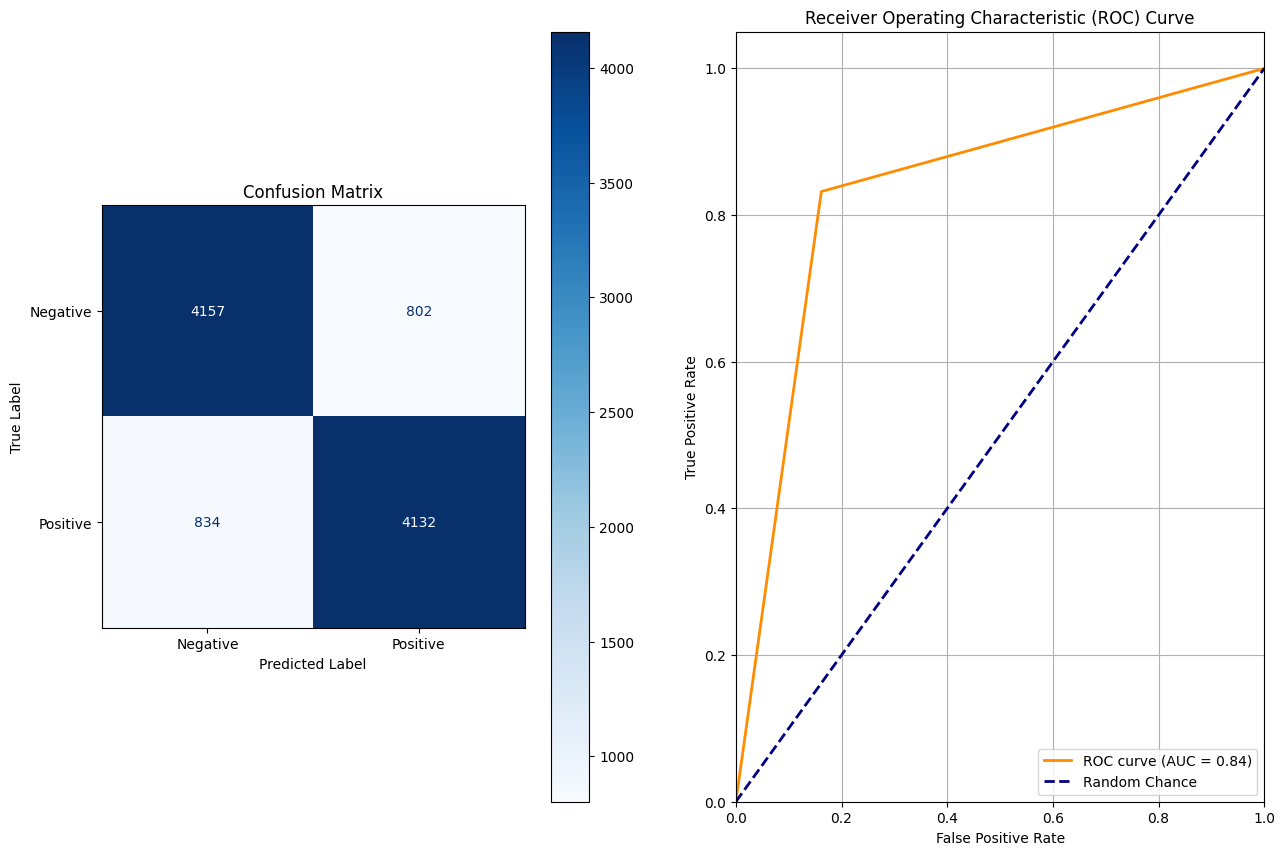

In [ ]:
full_model_3_checkpoint = 'results_frozen_False_epochs_3_0/checkpoint-13000'
test_model(full_model_3_checkpoint, val_data)